# Test the "Momentum" Trading Strategy

This interactive nootebook tests the "momentum" trading strategy and provides some plots for data anlysis.

## Import Packages

In [1]:
from tradelab import *
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import math

## Define and Execute Trading Strategy

Define key parameters

In [2]:
tickers = [
    "XLE",  # Energy
    "XLF",  # Financials
    "XLU",  # Utilities
    "XLI",  # Industrials
    "XLK",  # Technology
    "XLV",  # Healthcare
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLB",  # Materials
    "IYR",  # Real Estate
    "IYE",  # Energy (iShares)
    "OIH",  # Oil Services
    "SMH",  # Semiconductors
    "IBB"   # Biotechnology
]

cash = 1000
start_time = "2010-01-01"
end_time = "2026-01-01"

Create data handler, portfolio, strategy and trading engine.

In [3]:
data_handler = YFinanceDataHandler(
    tickers=tickers,
    start_time=start_time,
    end_time=end_time)

position_sizer = PositionSizer()

portfolio = Portfolio(deposit=cash)

strategy = Momentum(
    tickers=tickers,
    start_time=start_time,
    end_time=end_time,
    offset="30D",
    rebalance_frequency = 30, 
    momentum_lookback = 7,
    buy_top_n = 1
)

engine = TradingEngine(
    portfolio = portfolio,
    strategy = strategy,
    data_handler = data_handler,
    position_sizer = position_sizer
)

[*********************100%***********************]  14 of 14 completed


For comparison run a buy-and-hold strategy with the MSCI World

In [4]:
msci_data_handler = YFinanceDataHandler(
    tickers=["IWDA.AS"],
    start_time=start_time,
    end_time=end_time)

msci_portfolio = Portfolio(deposit=cash)

msci_strategy = BuyAndHold(
    tickers=["IWDA.AS"],
    start_time=start_time,
    end_time=end_time,
    offset="7D"
)

msci_engine = TradingEngine(
    portfolio = msci_portfolio,
    strategy = msci_strategy,
    data_handler = msci_data_handler,
    position_sizer = position_sizer
)

[*********************100%***********************]  1 of 1 completed


Run backtests

In [5]:
momentum_history = engine.run_backtest()
msci_history = msci_engine.run_backtest()


Backtesting complete.
Backtesting complete.


## Visualize Performance

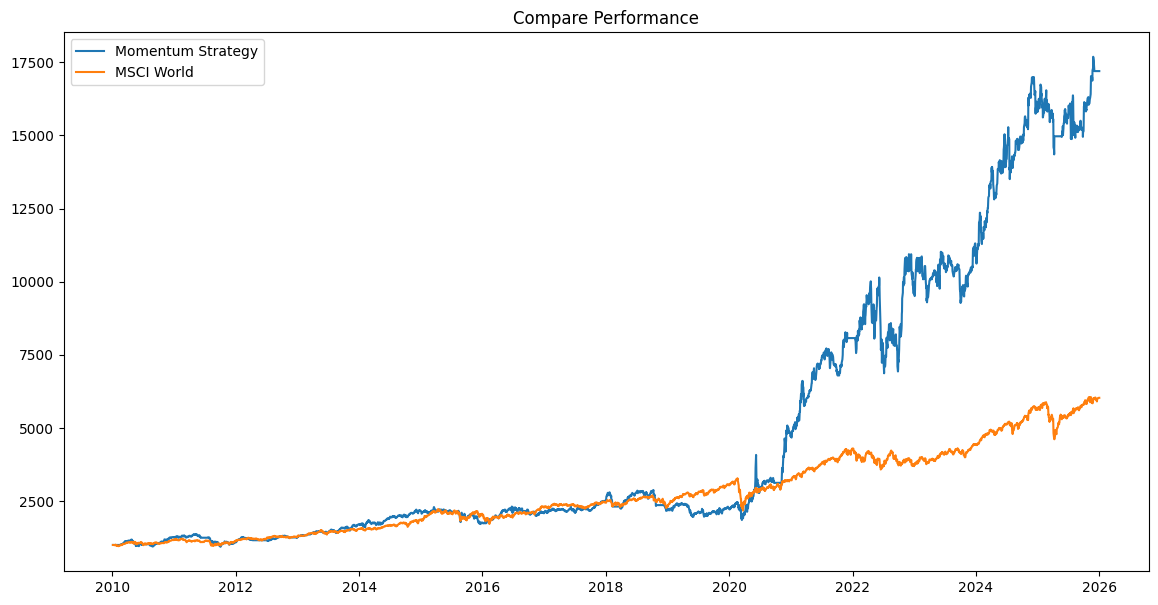

In [6]:
x1, y1 = zip(*((h['timestamp'], h['total_value']) for h in momentum_history))
x2, y2 = zip(*((h['timestamp'], h['total_value']) for h in msci_history))

plt.figure(figsize=(14, 7))
plt.plot(x1,y1, label="Momentum Strategy")
plt.plot(x2,y2, label="MSCI World")
plt.title("Compare Performance")
plt.legend()
plt.show()

Evaluate Performance

In [7]:
print(f"Total Momentum Strategy Return: {y1[-1]/y1[0]:.2%}")
print(f"Total MSCI World Return: {y2[-1]/y2[0]:.2%}")

Total Momentum Strategy Return: 1720.04%
Total MSCI World Return: 603.04%


## License

This file is part of TradeLab.

Copyright © 2026 Hannes Malcha

TradeLab is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

TradeLab is distributed in the hope that it will be useful, 
but WITHOUT ANY WARRANTY; without even the implied warranty of 
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the 
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with TradeLab. If not, see https://www.gnu.org/licenses/.